In [6]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import shutil
import random

In [7]:
data="/content/drive/MyDrive/Garbage classification"

In [8]:
# from google.colab import drive
# drive.mount('/content/drive')

In [9]:
images=[]
labels=[]

for folder in os.listdir(data):
  path=os.path.join(data,folder)
  print(folder)

paper
cardboard
plastic
glass
metal
trash


In [10]:
for image_name in os.listdir(path):
  image_path=os.path.join(path,image_name)

  print(image_path)

/content/drive/MyDrive/Garbage classification/trash/trash107.jpg
/content/drive/MyDrive/Garbage classification/trash/trash123.jpg
/content/drive/MyDrive/Garbage classification/trash/trash122.jpg
/content/drive/MyDrive/Garbage classification/trash/trash103.jpg
/content/drive/MyDrive/Garbage classification/trash/trash119.jpg
/content/drive/MyDrive/Garbage classification/trash/trash125.jpg
/content/drive/MyDrive/Garbage classification/trash/trash129.jpg
/content/drive/MyDrive/Garbage classification/trash/trash110.jpg
/content/drive/MyDrive/Garbage classification/trash/trash114.jpg
/content/drive/MyDrive/Garbage classification/trash/trash12.jpg
/content/drive/MyDrive/Garbage classification/trash/trash10.jpg
/content/drive/MyDrive/Garbage classification/trash/trash102.jpg
/content/drive/MyDrive/Garbage classification/trash/trash105.jpg
/content/drive/MyDrive/Garbage classification/trash/trash11.jpg
/content/drive/MyDrive/Garbage classification/trash/trash116.jpg
/content/drive/MyDrive/Garba

In [11]:
img=cv2.imread(image_path)

In [12]:
images.append(img)
labels.append(folder)

In [13]:
for folder in os.listdir(data):
  path=os.path.join(data,folder)
  for image_name in os.listdir(path):
    image_path=os.path.join(path,image_name)
    img=cv2.imread(image_path)

    if img is None:
      print("Corrupted", image_path)

**Checking Blur images using Laplacian Technique**

In [14]:
threshold = 15
blur_count=0

new_path ="/content/drive/MyDrive/Vasantha leela /Garbage classification/Blur_Images"
os.makedirs(new_path, exist_ok=True)

for folder in os.listdir(data):

    folder_path = os.path.join(data, folder)

    if not os.path.isdir(folder_path):
        continue

    print(f"\nProcessing Folder: {folder}")


    for image_name in os.listdir(folder_path):

        image_path = os.path.join(folder_path, image_name)


        img = cv2.imread(image_path)


        if img is None:
            print(f"Cannot read image: {image_name}")
            continue


        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


        blur_value = cv2.Laplacian(gray, cv2.CV_64F).var()

        print(f"{image_name} --> Blur Score: {blur_value:.2f}")


        if blur_value < threshold:
            blur_count += 1
            print(f"Blurry Image: {image_name}")

            blur_destination = os.path.join(new_path, image_name)
            shutil.move(image_path, blur_destination)

        else:
            print(f"Clear Image: {image_name}")
print("Total Blurry Images Removed:", blur_count)

Streaming output truncated to the last 5000 lines.
Clear Image: paper142.jpg
paper133.jpg --> Blur Score: 781.18
Clear Image: paper133.jpg
paper143.jpg --> Blur Score: 92.63
Clear Image: paper143.jpg
paper128.jpg --> Blur Score: 223.19
Clear Image: paper128.jpg
paper135.jpg --> Blur Score: 1094.81
Clear Image: paper135.jpg
paper146.jpg --> Blur Score: 162.64
Clear Image: paper146.jpg
paper152.jpg --> Blur Score: 647.70
Clear Image: paper152.jpg
paper131.jpg --> Blur Score: 694.54
Clear Image: paper131.jpg
paper129.jpg --> Blur Score: 800.68
Clear Image: paper129.jpg
paper144.jpg --> Blur Score: 632.43
Clear Image: paper144.jpg
paper149.jpg --> Blur Score: 85.64
Clear Image: paper149.jpg
paper148.jpg --> Blur Score: 788.20
Clear Image: paper148.jpg
paper137.jpg --> Blur Score: 155.65
Clear Image: paper137.jpg
paper150.jpg --> Blur Score: 235.53
Clear Image: paper150.jpg
paper141.jpg --> Blur Score: 399.49
Clear Image: paper141.jpg
paper145.jpg --> Blur Score: 273.30
Clear Image: paper14

In [16]:
print(len(os.listdir("/content/drive/MyDrive/Garbage classification/Blur_Images")))

112


**To check duplicate images**

In [17]:
unique = set()

for folder in os.listdir(data):
  path=os.path.join(data,folder)

  for image_name in os.listdir(path):
    image_path=os.path.join(path,image_name)

    img=cv2.imread(image_path)

    if img is None:
      print(f"Warning: Could not read image {image_path}. Skipping duplicate check for this entry.")
      continue

    image_bytes=img.tobytes()

    if image_bytes in unique:
      print("Duplicate:", image_name)
      os.remove(image_path)

    else:
      unique.add(image_bytes)

Duplicate: glass176.jpg
Duplicate: glass389.jpg
Duplicate: metal91.jpg


**Noise Removal**

In [18]:
noisy_count=0
threshold=75

new_path="/content/drive/MyDrive/Garbage classification/Noisy_Images"
os.makedirs(new_path,exist_ok=True)

for folder in os.listdir(data):
  path=os.path.join(data,folder)

  for image_name in os.listdir(path):
    image_path=os.path.join(path,image_name)

    img=cv2.imread(image_path)

    if img is None:
      print(f"Warning: Could not read image {image_path}. Skipping.")
      continue

    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

    noise_value=gray.std()

    if noise_value>threshold:
      print("Noisy Image:", image_name)

      noisy_count += 1
      denoised = cv2.GaussianBlur(img, (5,5), 0)
      noise_destination_path=os.path.join(new_path,image_name)
      shutil.move(image_path,noise_destination_path)

print("Total Noisy Images:", noisy_count)

Noisy Image: paper111.jpg
Noisy Image: paper127.jpg
Noisy Image: paper176.jpg
Noisy Image: paper23.jpg
Noisy Image: paper237.jpg
Noisy Image: paper262.jpg
Noisy Image: paper29.jpg
Noisy Image: paper289.jpg
Noisy Image: paper316.jpg
Noisy Image: paper332.jpg
Noisy Image: paper365.jpg
Noisy Image: paper391.jpg
Noisy Image: paper410.jpg
Noisy Image: paper443.jpg
Noisy Image: paper435.jpg
Noisy Image: paper451.jpg
Noisy Image: paper450.jpg
Noisy Image: paper452.jpg
Noisy Image: paper490.jpg
Noisy Image: paper494.jpg
Noisy Image: paper540.jpg
Noisy Image: paper556.jpg
Noisy Image: paper569.jpg
Noisy Image: paper97.jpg
Noisy Image: cardboard124.jpg
Noisy Image: cardboard149.jpg
Noisy Image: cardboard168.jpg
Noisy Image: cardboard268.jpg
Noisy Image: cardboard298.jpg
Noisy Image: cardboard41.jpg
Noisy Image: plastic199.jpg
Noisy Image: plastic198.jpg
Noisy Image: plastic196.jpg
Noisy Image: plastic216.jpg
Noisy Image: plastic40.jpg
Noisy Image: plastic68.jpg
Noisy Image: plastic95.jpg
Noisy I

In [19]:
print(len(os.listdir("/content/drive/MyDrive/Garbage classification/Noisy_Images")))

94


**Data Augmentation**

In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

ignore_folders = [

    "Blur_Images",

    "Noisy_Images",

    "Augmented_dataset",

    ".ipynb_checkpoints"
]

augment="/content/drive/MyDrive/Garbage classification/Augmented_dataset"
os.makedirs(augment,exist_ok=True)

datagen=ImageDataGenerator(
        rotation_range=20,
        horizontal_flip=True,
        width_shift_range=0.2,
        vertical_flip=True,
        zoom_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        brightness_range=[0.5,1.5],
        channel_shift_range=20,
        fill_mode='nearest'
    )
for folder in os.listdir(data):

  if folder in ignore_folders:
        continue

  path=os.path.join(data,folder)

  if not os.path.isdir(path):
    continue

  augmented=os.path.join(augment,folder)
  os.makedirs(augmented, exist_ok=True)

  for image_name in os.listdir(path):
    image_path=os.path.join(path,image_name)
    img=cv2.imread(image_path)

    if img is None:
      print(f"Warning: Could not read image {image_path}. Skipping.")
      continue

    img=cv2.resize(img,(224,224))
    img=img.reshape((1,)+img.shape)

    i=0
    for batch in datagen.flow(img,batch_size=1,save_to_dir=augmented,save_prefix='aug',save_format='jpg'):

      i+=1
      if i == 3:
        break
print("Augmentation Completed")


Augmentation Completed


In [21]:
df="/content/drive/MyDrive/Garbage classification/Augmented_dataset"

for folder in os.listdir(df):
  path=os.path.join(df,folder)
  print(folder)

paper
cardboard
plastic
glass
metal
trash


In [22]:
for folder in os.listdir(df):

    path = os.path.join(df, folder)

    if os.path.isdir(path):

        print(folder, len(os.listdir(path)))

paper 1499
cardboard 1067
plastic 1235
glass 1224
metal 1077
trash 385


In [23]:
new = "/content/drive/MyDrive/Garbage classification/New_augmented_dataset"
os.makedirs(new, exist_ok = True)

ignore_folders = [
    ".ipynb_checkpoints"
]

for folder in os.listdir(df):

  if folder in ignore_folders:
        continue

  path=os.path.join(df,folder)
  os.makedirs(os.path.join(new, folder), exist_ok=True)

  images=os.listdir(path)

  select=random.sample(images,min(500,len(images)))

  for image in select:

      source=os.path.join(path,image)
      destination=os.path.join(new,folder,image)
      shutil.copy(source,destination)

      print(folder, "completed")

print("Done")

paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper completed
paper co

In [24]:
new = "/content/drive/MyDrive/Garbage classification/New_augmented_dataset"

In [25]:
image=[]
label=[]

for folder in os.listdir(new):
  path=os.path.join(new,folder)

  for image_name in os.listdir(path):
    image_path=os.path.join(path,image_name)

    img=cv2.imread(image_path)

    image.append(img)
    label.append(folder)

In [27]:
# print(folder)

In [26]:
X=np.array(image)
y=np.array(label)

In [28]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
y=le.fit_transform(y)

In [29]:
from sklearn.model_selection import train_test_split

X_train,X_temp,y_train,y_temp=train_test_split(X,y,test_size=0.3,random_state=42)

In [30]:
X_val,X_test,y_val,y_test=train_test_split(X_temp,y_temp,test_size=0.5,random_state=42)

In [31]:
X_train=X_train/255
X_val=X_val/255
X_test=X_test/255

In [32]:
for folder in os.listdir(data):

    path = os.path.join(data, folder)

    if os.path.isdir(path):

        print(folder, len(os.listdir(path)))

paper 553
cardboard 382
plastic 437
glass 440
metal 379
trash 130
Blur_Images 109
Noisy_Images 94
Augmented_dataset 6
New_augmented_dataset 6


In [33]:
class_to_idx = dict(zip(le.classes_, le.transform(le.classes_)))
print(class_to_idx)

{np.str_('cardboard'): np.int64(0), np.str_('glass'): np.int64(1), np.str_('metal'): np.int64(2), np.str_('paper'): np.int64(3), np.str_('plastic'): np.int64(4), np.str_('trash'): np.int64(5)}


In [34]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models
from torch.utils.data import DataLoader,TensorDataset

In [35]:
model = models.mobilenet_v2(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 75.6MB/s]


In [36]:
for param in model.parameters():

    param.requires_grad = False

In [37]:
model.classifier = nn.Sequential(

    nn.Linear(1280,128),

    nn.ReLU(),

    nn.Dropout(0.5),

    nn.Linear(128, 6)
)
print(model)

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [38]:
criterion=nn.CrossEntropyLoss()

In [39]:
optimizer=optim.Adam(model.classifier.parameters(),lr=0.001)

**CONVERT DATAS INTO TENSOR**

In [40]:
X_train=torch.tensor(X_train,dtype=torch.float32)
y_train=torch.tensor(y_train,dtype=torch.long)

X_test=torch.tensor(X_test,dtype=torch.float32)
y_test=torch.tensor(y_test,dtype=torch.long)

X_val=torch.tensor(X_val,dtype=torch.float32)
y_val=torch.tensor(y_val,dtype=torch.long)

In [41]:
X_train=X_train.permute(0,3,1,2)
X_test=X_test.permute(0,3,1,2)
X_val=X_val.permute(0,3,1,2)

In [42]:
train_dataset=TensorDataset(X_train,y_train)
test_dataset=TensorDataset(X_test,y_test)
val_dataset=TensorDataset(X_val,y_val)

In [43]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=False)
val_loader=DataLoader(val_dataset,batch_size=32,shuffle=False)

In [44]:
print(X_train.shape,y_train.shape,X_test.shape,y_test.shape,X_val.shape,y_val.shape)

torch.Size([2019, 3, 224, 224]) torch.Size([2019]) torch.Size([433, 3, 224, 224]) torch.Size([433]) torch.Size([433, 3, 224, 224]) torch.Size([433])


In [45]:
device=torch.device("cuda"
                    if torch.cuda.is_available()
                    else "cpu")

model=model.to(device)

In [46]:
num_epoch=20

for epoch in range(num_epoch):
  model.train()

  running_loss=0.0
  correct=0
  total=0

  for image,label in train_loader:
    image=image.to(device)
    label=label.to(device)

    optimizer.zero_grad()
    outputs=model(image)

    loss=criterion(outputs,label)
    loss.backward()
    optimizer.step()

    running_loss+=loss.item()
    _,predicted=torch.max(outputs,1)
    total+=label.size(0)
    correct+=(predicted==label).sum().item()

  accuracy=100*correct/total

  print(f"Epoch {epoch+1}")
  print(f"Loss {running_loss:.4f}")
  print(f"Accuracy {accuracy:.2f}")

Epoch 1
Loss 83.0373
Accuracy 50.72
Epoch 2
Loss 56.6522
Accuracy 69.39
Epoch 3
Loss 51.2545
Accuracy 72.31
Epoch 4
Loss 45.8349
Accuracy 74.59
Epoch 5
Loss 41.3981
Accuracy 76.82
Epoch 6
Loss 40.7866
Accuracy 76.82
Epoch 7
Loss 38.0281
Accuracy 79.05
Epoch 8
Loss 36.6478
Accuracy 79.05
Epoch 9
Loss 34.8934
Accuracy 80.93
Epoch 10
Loss 34.9651
Accuracy 80.09
Epoch 11
Loss 33.7011
Accuracy 80.68
Epoch 12
Loss 30.0568
Accuracy 82.52
Epoch 13
Loss 30.4962
Accuracy 82.32
Epoch 14
Loss 29.6167
Accuracy 83.16
Epoch 15
Loss 28.2592
Accuracy 84.35
Epoch 16
Loss 27.7863
Accuracy 84.30
Epoch 17
Loss 27.4308
Accuracy 84.74
Epoch 18
Loss 26.7691
Accuracy 84.74
Epoch 19
Loss 26.4368
Accuracy 85.29
Epoch 20
Loss 27.3665
Accuracy 84.94


In [47]:
y_pred = []
y_true = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        y_pred.extend(predicted.cpu().numpy())

        y_true.extend(labels.numpy())

In [48]:
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,f1_score)

print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred))
print("F1 Score:",f1_score(y_true, y_pred, average='weighted'))
print(confusion_matrix(y_true, y_pred))

Accuracy: 0.8036951501154734
              precision    recall  f1-score   support

           0       0.96      0.88      0.92        74
           1       0.78      0.74      0.76        69
           2       0.74      0.90      0.81        68
           3       0.77      0.82      0.80        78
           4       0.97      0.68      0.80        84
           5       0.66      0.83      0.74        60

    accuracy                           0.80       433
   macro avg       0.81      0.81      0.80       433
weighted avg       0.82      0.80      0.81       433

F1 Score: 0.8052439676298258
[[65  0  0  7  0  2]
 [ 0 51 10  0  2  6]
 [ 1  4 61  0  0  2]
 [ 0  1  3 64  0 10]
 [ 0  8  6  7 57  6]
 [ 2  1  2  5  0 50]]


In [49]:
from sklearn.metrics import confusion_matrix

import seaborn as sns

import matplotlib.pyplot as plt

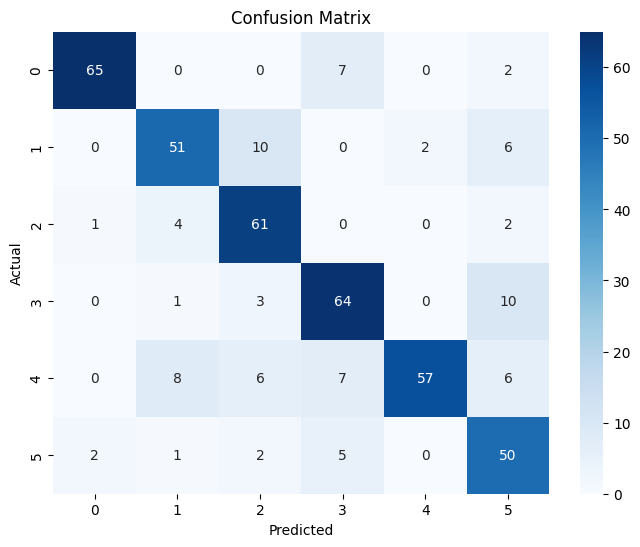

In [50]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [51]:
import pickle

pickle.dump(model,open("model.pkl","wb"))

In [52]:
loaded_model = pickle.load(open("model.pkl", "rb"))

loaded_model = loaded_model.to(device)

loaded_model.eval()

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [53]:
from sklearn.metrics import accuracy_score

y_pred = []
y_true = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = loaded_model(images)

        _, predicted = torch.max(outputs, 1)

        y_pred.extend(predicted.cpu().numpy())
        y_true.extend(labels.numpy())

print("Accuracy:", accuracy_score(y_true, y_pred))

Accuracy: 0.8036951501154734


In [54]:
model=models.efficientnet_b0(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 171MB/s]


In [55]:
for param in model.parameters():
  param.requires_grad = True

In [56]:
model.classifier=nn.Sequential(
    nn.Linear(1280,128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128,6)
)

In [57]:
criterion=nn.CrossEntropyLoss()

In [58]:
optimizer=optim.Adam(model.parameters(),lr=0.0001)

In [59]:
model=model.to(device)

In [60]:
num_epoch=20

for epoch in range(num_epoch):
  model.train()

  running_loss=0.0
  correct=0
  total=0

  for image,label in train_loader:
    image=image.to(device)
    label=label.to(device)

    optimizer.zero_grad()
    outputs=model(image)

    loss=criterion(outputs,label)
    loss.backward()
    optimizer.step()

    running_loss+=loss.item()
    _,predicted=torch.max(outputs,1)
    total+=label.size(0)
    correct+=(predicted==label).sum().item()

  accuracy=100*correct/total

  print(f"Epoch {epoch+1}")
  print(f"Loss {running_loss:.4f}")
  print(f"Accuracy {accuracy:.2f}")

Epoch 1
Loss 100.1015
Accuracy 48.14
Epoch 2
Loss 55.3807
Accuracy 74.59
Epoch 3
Loss 32.9523
Accuracy 85.49
Epoch 4
Loss 18.0520
Accuracy 92.12
Epoch 5
Loss 10.5628
Accuracy 96.14
Epoch 6
Loss 9.1723
Accuracy 97.13
Epoch 7
Loss 7.9182
Accuracy 97.13
Epoch 8
Loss 5.5060
Accuracy 97.97
Epoch 9
Loss 3.6045
Accuracy 98.46
Epoch 10
Loss 4.4384
Accuracy 98.42
Epoch 11
Loss 4.5121
Accuracy 98.02
Epoch 12
Loss 3.2525
Accuracy 98.81
Epoch 13
Loss 3.8927
Accuracy 98.27
Epoch 14
Loss 2.7175
Accuracy 98.91
Epoch 15
Loss 2.8878
Accuracy 99.16
Epoch 16
Loss 3.3739
Accuracy 98.86
Epoch 17
Loss 5.4730
Accuracy 99.01
Epoch 18
Loss 3.2079
Accuracy 98.56
Epoch 19
Loss 2.9145
Accuracy 98.91
Epoch 20
Loss 5.5121
Accuracy 98.66


In [61]:
y_pred = []
y_true = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        y_pred.extend(predicted.cpu().numpy())

        y_true.extend(labels.numpy())

In [62]:
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,f1_score)

print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred))
print("F1 Score:",f1_score(y_true, y_pred, average='weighted'))
print(confusion_matrix(y_true, y_pred))

Accuracy: 0.9260969976905312
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        74
           1       0.93      1.00      0.97        69
           2       0.89      0.96      0.92        68
           3       0.94      0.87      0.91        78
           4       0.94      0.92      0.93        84
           5       0.84      0.87      0.85        60

    accuracy                           0.93       433
   macro avg       0.92      0.93      0.92       433
weighted avg       0.93      0.93      0.93       433

F1 Score: 0.9261481393067669
[[70  0  0  2  0  2]
 [ 0 69  0  0  0  0]
 [ 0  3 65  0  0  0]
 [ 0  0  1 68  2  7]
 [ 0  2  3  1 77  1]
 [ 0  0  4  1  3 52]]


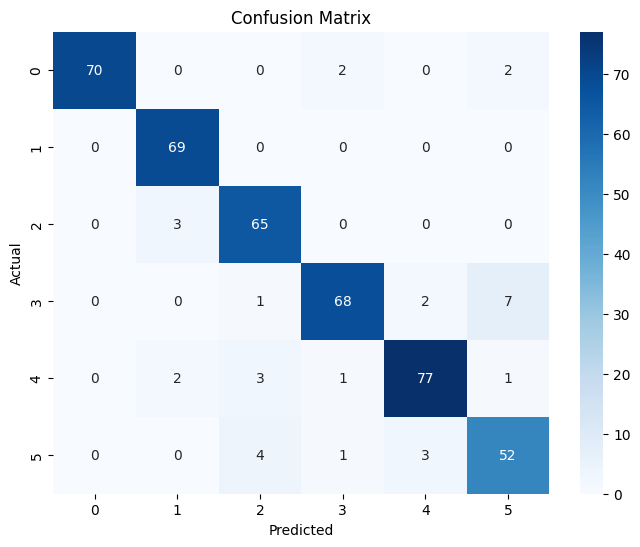

In [63]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [64]:
import pickle

pickle.dump(model,open("model1.pkl","wb"))

In [65]:
loaded_model = pickle.load(open("model1.pkl", "rb"))

loaded_model = loaded_model.to(device)

loaded_model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [66]:
from sklearn.metrics import accuracy_score

y_pred = []
y_true = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = loaded_model(images)

        _, predicted = torch.max(outputs, 1)

        y_pred.extend(predicted.cpu().numpy())
        y_true.extend(labels.numpy())

print("Accuracy:", accuracy_score(y_true, y_pred))

Accuracy: 0.9260969976905312


In [67]:
print(classification_report(
    y_true,
    y_pred,
    target_names=[
        'cardboard',
        'glass',
        'metal',
        'paper',
        'plastic',
        'trash'
    ]
))

              precision    recall  f1-score   support

   cardboard       1.00      0.95      0.97        74
       glass       0.93      1.00      0.97        69
       metal       0.89      0.96      0.92        68
       paper       0.94      0.87      0.91        78
     plastic       0.94      0.92      0.93        84
       trash       0.84      0.87      0.85        60

    accuracy                           0.93       433
   macro avg       0.92      0.93      0.92       433
weighted avg       0.93      0.93      0.93       433



In [68]:
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Test Accuracy:", 100 * correct / total)

Test Accuracy: 92.60969976905312


In [69]:
model=models.resnet50(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 171MB/s]


In [70]:
for param in model.parameters():
  param.requires_grad=True

In [71]:
model.fc=nn.Sequential(
    nn.Linear(2048,128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128,6)
)

criterian=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.fc.parameters(),lr=0.001)

In [72]:
model=model.to(device)

In [73]:
num_epoch=20

for epoch in range(num_epoch):
  model.train()

  running_loss=0.0
  correct=0
  total=0

  for image,label in train_loader:
    image=image.to(device)
    label=label.to(device)

    optimizer.zero_grad()
    outputs=model(image)

    loss=criterion(outputs,label)
    loss.backward()
    optimizer.step()

    running_loss+=loss.item()
    _,predicted=torch.max(outputs,1)
    total+=label.size(0)
    correct+=(predicted==label).sum().item()

  accuracy=100*correct/total

  print(f"Epoch {epoch+1}")
  print(f"Loss {running_loss:.4f}")
  print(f"Accuracy {accuracy:.2f}")

Epoch 1
Loss 89.0238
Accuracy 46.61
Epoch 2
Loss 67.7772
Accuracy 60.82
Epoch 3
Loss 58.1650
Accuracy 67.31
Epoch 4
Loss 52.9036
Accuracy 71.12
Epoch 5
Loss 51.3171
Accuracy 71.87
Epoch 6
Loss 49.1884
Accuracy 73.40
Epoch 7
Loss 47.7943
Accuracy 72.46
Epoch 8
Loss 42.9552
Accuracy 75.88
Epoch 9
Loss 48.8790
Accuracy 72.96
Epoch 10
Loss 44.1590
Accuracy 73.90
Epoch 11
Loss 43.2695
Accuracy 75.68
Epoch 12
Loss 43.5383
Accuracy 75.24
Epoch 13
Loss 42.4066
Accuracy 75.58
Epoch 14
Loss 42.3464
Accuracy 75.14
Epoch 15
Loss 42.1985
Accuracy 76.23
Epoch 16
Loss 44.3356
Accuracy 74.64
Epoch 17
Loss 46.4424
Accuracy 74.59
Epoch 18
Loss 42.6845
Accuracy 76.57
Epoch 19
Loss 38.2106
Accuracy 79.05
Epoch 20
Loss 41.2979
Accuracy 76.47


In [74]:
y_pred = []
y_true = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        y_pred.extend(predicted.cpu().numpy())

        y_true.extend(labels.numpy())

In [75]:
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,f1_score)

print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred))
print("F1 Score:",f1_score(y_true, y_pred, average='weighted'))
print(confusion_matrix(y_true, y_pred))

Accuracy: 0.7598152424942263
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        74
           1       0.64      0.83      0.72        69
           2       0.68      0.84      0.75        68
           3       0.78      0.82      0.80        78
           4       0.92      0.67      0.77        84
           5       0.70      0.50      0.58        60

    accuracy                           0.76       433
   macro avg       0.77      0.75      0.75       433
weighted avg       0.77      0.76      0.76       433

F1 Score: 0.7575497114502344
[[65  0  1  6  0  2]
 [ 1 57  7  1  2  1]
 [ 0 10 57  1  0  0]
 [ 5  0  1 64  1  7]
 [ 0 16  6  3 56  3]
 [ 3  6 12  7  2 30]]


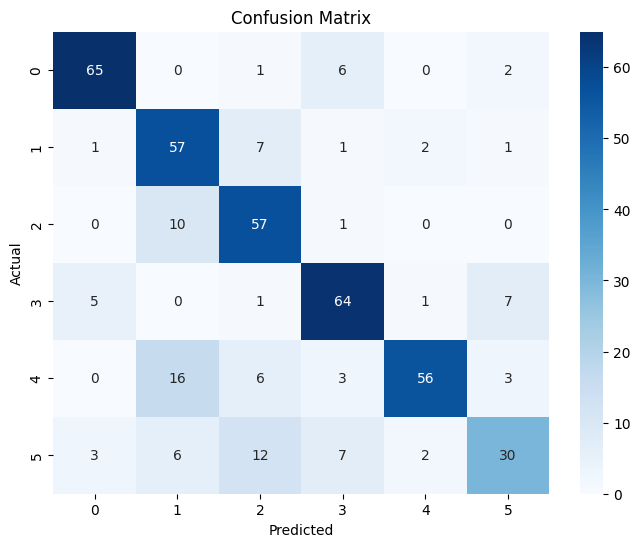

In [76]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [77]:
model = models.mobilenet_v3_small(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 137MB/s]


In [78]:
for param in model.parameters():
    param.requires_grad = True

In [79]:
model.classifier = nn.Sequential(
    nn.Linear(576, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 6)
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.classifier.parameters(),
    lr=0.001
)

In [80]:
model = model.to(device)

In [81]:
num_epoch=20

for epoch in range(num_epoch):
  model.train()

  running_loss=0.0
  correct=0
  total=0

  for image,label in train_loader:
    image=image.to(device)
    label=label.to(device)

    optimizer.zero_grad()
    outputs=model(image)

    loss=criterion(outputs,label)
    loss.backward()
    optimizer.step()

    running_loss+=loss.item()
    _,predicted=torch.max(outputs,1)
    total+=label.size(0)
    correct+=(predicted==label).sum().item()

  accuracy=100*correct/total

  print(f"Epoch {epoch+1}")
  print(f"Loss {running_loss:.4f}")
  print(f"Accuracy {accuracy:.2f}")

Epoch 1
Loss 90.6757
Accuracy 46.16
Epoch 2
Loss 64.8489
Accuracy 63.05
Epoch 3
Loss 58.5408
Accuracy 66.27
Epoch 4
Loss 52.6900
Accuracy 68.90
Epoch 5
Loss 49.2031
Accuracy 72.31
Epoch 6
Loss 46.2252
Accuracy 73.16
Epoch 7
Loss 42.7245
Accuracy 76.03
Epoch 8
Loss 43.3671
Accuracy 76.52
Epoch 9
Loss 41.1723
Accuracy 78.11
Epoch 10
Loss 39.2070
Accuracy 78.21
Epoch 11
Loss 36.7307
Accuracy 80.29
Epoch 12
Loss 35.5202
Accuracy 80.09
Epoch 13
Loss 34.6756
Accuracy 80.88
Epoch 14
Loss 32.3717
Accuracy 83.16
Epoch 15
Loss 33.3173
Accuracy 82.66
Epoch 16
Loss 31.9648
Accuracy 83.51
Epoch 17
Loss 30.6531
Accuracy 83.21
Epoch 18
Loss 31.2407
Accuracy 83.31
Epoch 19
Loss 28.2252
Accuracy 84.55
Epoch 20
Loss 27.2171
Accuracy 84.20


In [82]:
y_pred = []
y_true = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        y_pred.extend(predicted.cpu().numpy())

        y_true.extend(labels.numpy())

In [83]:
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,f1_score)

print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred))
print("F1 Score:",f1_score(y_true, y_pred, average='weighted'))
print(confusion_matrix(y_true, y_pred))

Accuracy: 0.7852193995381063
              precision    recall  f1-score   support

           0       0.92      0.81      0.86        74
           1       0.75      0.84      0.79        69
           2       0.86      0.79      0.82        68
           3       0.68      0.86      0.76        78
           4       0.82      0.69      0.75        84
           5       0.73      0.72      0.72        60

    accuracy                           0.79       433
   macro avg       0.79      0.79      0.79       433
weighted avg       0.80      0.79      0.79       433

F1 Score: 0.7860972353349911
[[60  1  0  9  1  3]
 [ 1 58  5  1  3  1]
 [ 1  8 54  2  3  0]
 [ 1  0  0 67  3  7]
 [ 1 10  3  7 58  5]
 [ 1  0  1 12  3 43]]


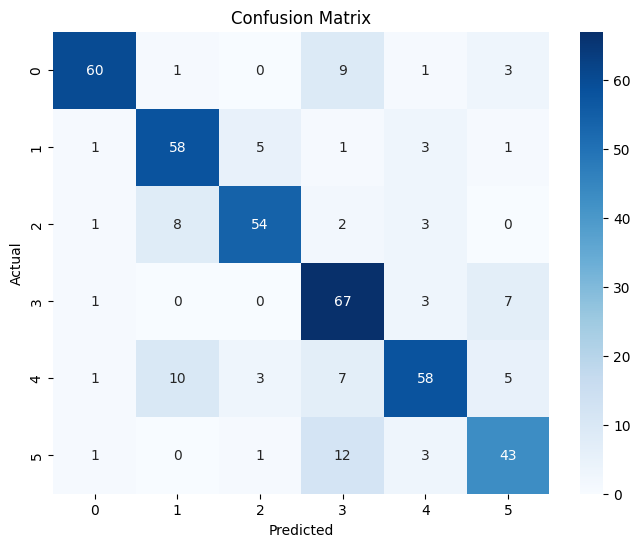

In [84]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [85]:
model = models.shufflenet_v2_x1_0(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1`. You can also use `weights=ShuffleNet_V2_X1_0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth


100%|██████████| 8.79M/8.79M [00:00<00:00, 137MB/s]


In [86]:
for param in model.parameters():
    param.requires_grad = True

In [87]:
model.fc = nn.Sequential(
    nn.Linear(1024, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 6)
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

In [88]:
num_epoch = 20

for epoch in range(num_epoch):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for image, label in train_loader:

        image = image.to(device)
        label = label.to(device)

        optimizer.zero_grad()

        outputs = model(image)

        loss = criterion(outputs, label)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * image.size(0)

        _, predicted = torch.max(outputs, 1)

        total += label.size(0)

        correct += (predicted == label).sum().item()

    epoch_loss = running_loss / total
    accuracy = 100 * correct / total

    print(f"Epoch {epoch+1}")
    print(f"Loss: {epoch_loss:.4f}")
    print(f"Accuracy: {accuracy:.2f}")

Epoch 1
Loss: 1.7279
Accuracy: 38.04
Epoch 2
Loss: 1.4940
Accuracy: 53.19
Epoch 3
Loss: 1.2762
Accuracy: 58.30
Epoch 4
Loss: 1.1279
Accuracy: 62.56
Epoch 5
Loss: 1.0239
Accuracy: 65.63
Epoch 6
Loss: 0.9529
Accuracy: 67.51
Epoch 7
Loss: 0.8888
Accuracy: 70.88
Epoch 8
Loss: 0.8315
Accuracy: 72.26
Epoch 9
Loss: 0.7891
Accuracy: 73.30
Epoch 10
Loss: 0.7651
Accuracy: 73.06
Epoch 11
Loss: 0.7257
Accuracy: 75.24
Epoch 12
Loss: 0.6663
Accuracy: 77.17
Epoch 13
Loss: 0.6815
Accuracy: 77.41
Epoch 14
Loss: 0.6382
Accuracy: 78.31
Epoch 15
Loss: 0.6166
Accuracy: 79.45
Epoch 16
Loss: 0.6060
Accuracy: 80.29
Epoch 17
Loss: 0.5945
Accuracy: 80.04
Epoch 18
Loss: 0.5730
Accuracy: 80.98
Epoch 19
Loss: 0.5541
Accuracy: 80.93
Epoch 20
Loss: 0.5408
Accuracy: 82.12


In [89]:
y_pred = []
y_true = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        y_pred.extend(predicted.cpu().numpy())

        y_true.extend(labels.numpy())

In [90]:
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,f1_score)

print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred))
print("F1 Score:",f1_score(y_true, y_pred, average='weighted'))
print(confusion_matrix(y_true, y_pred))

Accuracy: 0.8013856812933026
              precision    recall  f1-score   support

           0       0.94      0.86      0.90        74
           1       0.70      0.81      0.75        69
           2       0.82      0.82      0.82        68
           3       0.80      0.86      0.83        78
           4       0.81      0.76      0.79        84
           5       0.74      0.67      0.70        60

    accuracy                           0.80       433
   macro avg       0.80      0.80      0.80       433
weighted avg       0.81      0.80      0.80       433

F1 Score: 0.8017481963617911
[[64  0  0  6  1  3]
 [ 0 56  6  1  4  2]
 [ 0  8 56  0  2  2]
 [ 0  1  1 67  4  5]
 [ 0 10  2  6 64  2]
 [ 4  5  3  4  4 40]]


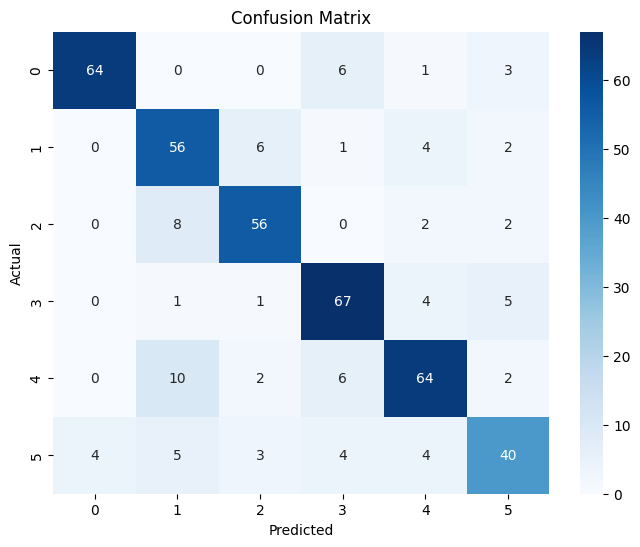

In [91]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

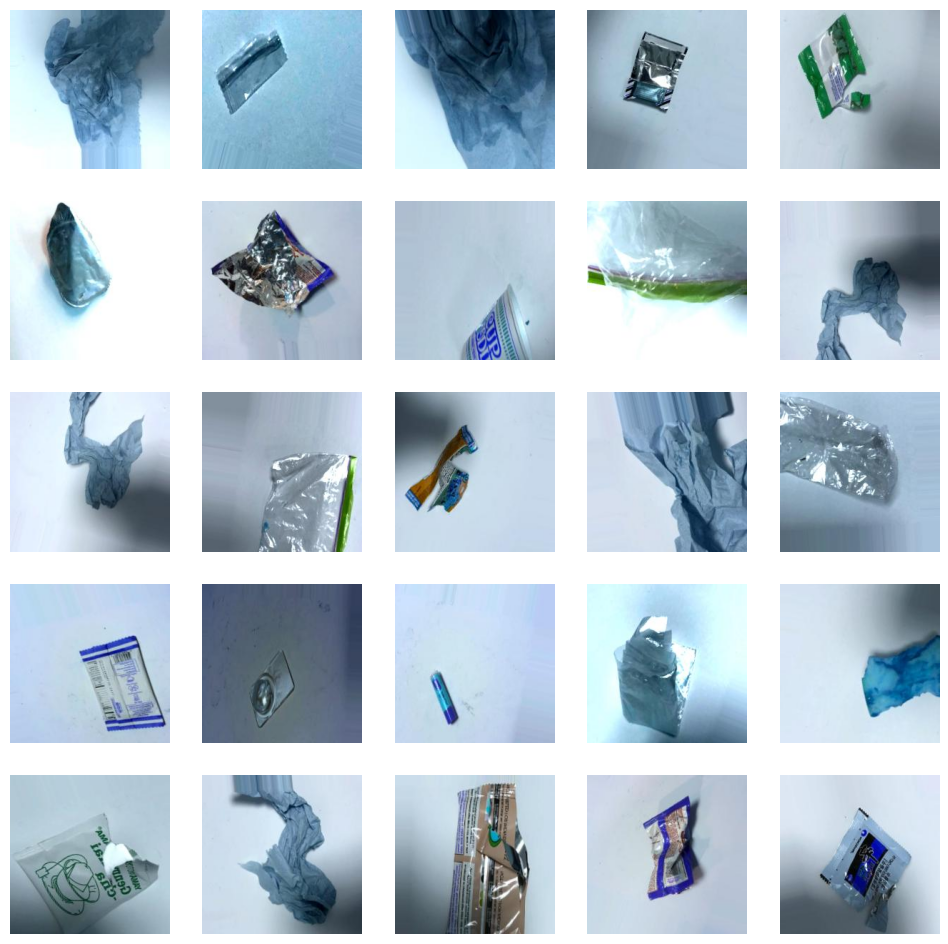

In [92]:
glass_indices = np.where(y == 5)[0]

plt.figure(figsize=(12,12))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(cv2.cvtColor(X[glass_indices[i]], cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.show()